# Object Detection with Annotation

# Step 1 - pos.txt with json

In [22]:
import os
import json
json_folder = './ann'
image_folders = 'pos/'
output_file = 'pos.txt'

with open(output_file, 'w') as f_out:
    for filename in os.listdir(json_folder):
        if not filename.endswith(".json"):
            continue
        json_path = os.path.join(json_folder, filename)
        # f_out.writ(json_path + '\n')           #for understand

        #Step 2 Read Json data:

        with open(json_path, "r") as f_in:
            data = json.load(f_in) #Reads the text inside the JSON file and transforms it into a searchable Python dictionary.


        # Step 3 FILENAME STRING MANIPULATION

        img_name = filename.replace(".json", "")
        img_path = f'{image_folders}{img_name}'

        wbc_boxes  = [] #Creates a clean, empty list variable named wbc_boxes. We will store the coordinates of any White Blood Cells we find inside this specific image here.

        # Step 4 Extracting Target Object Data
        #NESTED ITERATION & FILTERING

        #
        for obj in data.get("objects", []):
            #data.get("objects", []): Looks inside your JSON data map for the section marked "objects". If it finds it, it loops through the list of items inside it. If the key doesn't exist, it uses an empty list [] so it doesn't crash.

            if obj.get("classTitle") == "WBC":
                exterior = obj["points"]["exterior"]

                # Dives deep into your JSON structure: goes to the "points" section, then inside to the "exterior" section.
                #exterior =: Saves those coordinate pairings into a variable. Based on your JSON example, exterior now holds: [[109, 134], [324, 321]].

                xmin, ymin = exterior[0]
                xmax, ymax = exterior[1]
                w = xmax - xmin
                h = ymax - ymin

                wbc_boxes.append(f"{xmin} {ymin} {w} {h}")

            # Step 5 Saving to the Output Text File

            if len(wbc_boxes) > 0:  #If the list is not empty (meaning we found at least one White Blood Cell in this image), Python runs the block inside. If it's 0, it skips this image entirely.
                box_str = " ".join(wbc_boxes)

                #" ".join(...): Takes all the coordinate strings inside your list and fuses them together into one long single-line text string, separating them with a single empty space.

                #If there were two WBCs found, it would merge "109 134 215 187" and "400 200 50 50" into: "109 134 215 187 400 200 50 50".
                f_out.write(f"{img_path} {len(wbc_boxes)} {box_str}\n")


## Step 2 - bg.txt

In [23]:
import os

nef_file = 'neg'
with open('bg.txt', 'w') as f:
    for file in os.listdir(nef_file):
        path = os.path.join(nef_file, file)
        f.write( path + '\n')

## Step 3 - pos.vec

In [37]:
!opencv_createsamples -info pos.txt -num 408 -w 24 -h 24 -vec pos.vec

Info file name: pos.txt
Img file name: (NULL)
Vec file name: pos.vec
BG  file name: (NULL)
Num: 408
BG color: 0
BG threshold: 80
Invert: FALSE
Max intensity deviation: 40
Max x angle: 1.1
Max y angle: 1.1
Max z angle: 0.5
Show samples: FALSE
Width: 24
Height: 24
Max Scale: -1
RNG Seed: 12345
Create training samples from images collection...
Done. Created 408 samples


## Step 4 - Cascade training

In [39]:
!opencv_traincascade -data result/ -vec pos.vec -bg bg.txt -numPos 380 -numNeg 350 -numStages 10 -w 24 -h 24

PARAMETERS:
cascadeDirName: result/
vecFileName: pos.vec
bgFileName: bg.txt
numPos: 380
numNeg: 350
numStages: 10
precalcValBufSize[Mb] : 1024
precalcIdxBufSize[Mb] : 1024
acceptanceRatioBreakValue : -1
stageType: BOOST
featureType: HAAR
sampleWidth: 24
sampleHeight: 24
boostType: GAB
minHitRate: 0.995
maxFalseAlarmRate: 0.5
weightTrimRate: 0.95
maxDepth: 1
maxWeakCount: 100
mode: BASIC
Number of unique features given windowSize [24,24] : 162336

===== TRAINING 0-stage =====
<BEGIN
POS current samples: 1
POS current samples: 2
POS current samples: 3
POS current samples: 4
POS current samples: 5
POS current samples: 6
POS current samples: 7
POS current samples: 8
POS current samples: 9
POS current samples: 10
POS current samples: 11
POS current samples: 12
POS current samples: 13
POS current samples: 14
POS current samples: 15
POS current samples: 16
POS current samples: 17
POS current samples: 18
POS current samples: 19
POS current samples: 20
POS current samples: 21
POS current sample

## Step 5 - Implementing

Found 1 White Blood Cells.


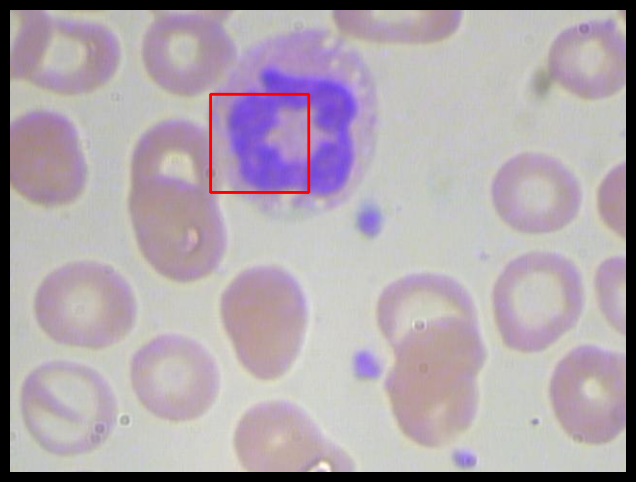

In [65]:
import cv2
from cv2 import CascadeClassifier
import matplotlib.pyplot as plt

# 1. DEFINE THE PATH AND LOAD THE ACTUAL IMAGE MATRIX
img_path = 'test/BloodImage_00296.jpeg'
img = cv2.imread(img_path)  # <-- FIX: Actually load the pixel data!

# 2. LOAD YOUR AI MODEL
cascade = cv2.CascadeClassifier('result/cascade.xml')

# 3. PREPARE THE GRAYSCALE IMAGE FOR COGNITION
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)  # <-- FIX: Pass the matrix, not the string path

# 4. RUN DETECTION
wbc = cascade.detectMultiScale(img_gray, scaleFactor=1.3, minNeighbors=8)
print(f"Found {len(wbc)} White Blood Cells.")

# 5. DRAW ALL BOXES ONTO THE IMAGE MATRIX
for (x, y, w, h) in wbc:
    cv2.rectangle(img, (x, y), (x + w, y + h), (0, 0, 255), 2)  # <-- FIX: Draw on 'img' matrix

# 6. CONVERT AND DISPLAY (OUTSIDE THE LOOP)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # <-- FIX: Moved outside the loop

plt.figure(figsize=(8, 6))
plt.imshow(img_rgb)
plt.axis('off')
plt.show()  # <-- FIX: Shows one clean, completed image!

Found 1 White Blood Cells.


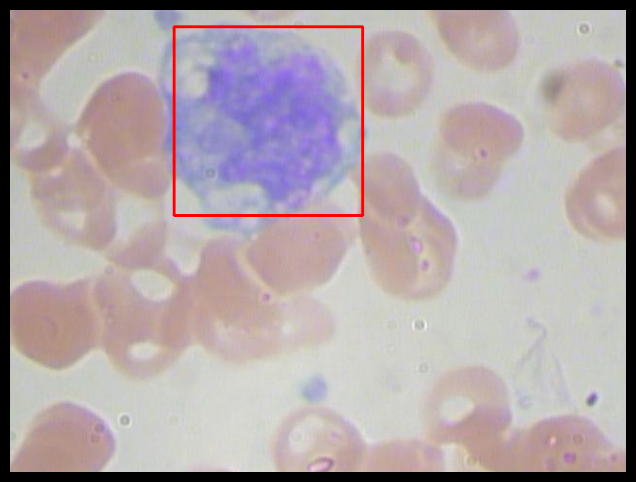

In [49]:
import cv2
from cv2 import CascadeClassifier
import matplotlib.pyplot as plt

# 1. DEFINE THE PATH AND LOAD THE ACTUAL IMAGE MATRIX
img_path = 'test/BloodImage_00015.jpeg'
img = cv2.imread(img_path)  # <-- FIX: Actually load the pixel data!

# 2. LOAD YOUR AI MODEL
cascade = cv2.CascadeClassifier('result/cascade.xml')

# 3. PREPARE THE GRAYSCALE IMAGE FOR COGNITION
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)  # <-- FIX: Pass the matrix, not the string path

# 4. RUN DETECTION
wbc = cascade.detectMultiScale(img_gray, scaleFactor=1.3, minNeighbors=3)
print(f"Found {len(wbc)} White Blood Cells.")

# 5. DRAW ALL BOXES ONTO THE IMAGE MATRIX
for (x, y, w, h) in wbc:
    cv2.rectangle(img, (x, y), (x + w, y + h), (0, 0, 255), 2)  # <-- FIX: Draw on 'img' matrix

# 6. CONVERT AND DISPLAY (OUTSIDE THE LOOP)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # <-- FIX: Moved outside the loop

plt.figure(figsize=(8, 6))
plt.imshow(img_rgb)
plt.axis('off')
plt.show()  # <-- FIX: Shows one clean, completed image!

Found 3 White Blood Cells.


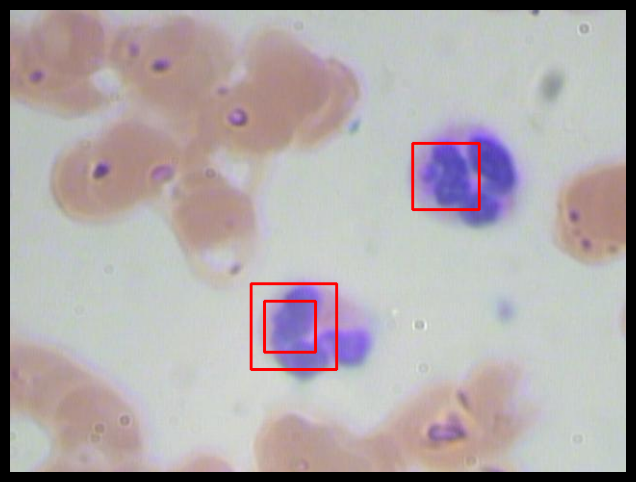

In [60]:
import cv2
from cv2 import CascadeClassifier
import matplotlib.pyplot as plt

# 1. DEFINE THE PATH AND LOAD THE ACTUAL IMAGE MATRIX
img_path = 'test/BloodImage_00065.jpeg'
img = cv2.imread(img_path)  # <-- FIX: Actually load the pixel data!

# 2. LOAD YOUR AI MODEL
cascade = cv2.CascadeClassifier('result/cascade.xml')

# 3. PREPARE THE GRAYSCALE IMAGE FOR COGNITION
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)  # <-- FIX: Pass the matrix, not the string path

# 4. RUN DETECTION
wbc = cascade.detectMultiScale(img_gray, scaleFactor=1.3, minNeighbors=3)
print(f"Found {len(wbc)} White Blood Cells.")

# 5. DRAW ALL BOXES ONTO THE IMAGE MATRIX
for (x, y, w, h) in wbc:
    cv2.rectangle(img, (x, y), (x + w, y + h), (0, 0, 255), 2)  # <-- FIX: Draw on 'img' matrix

# 6. CONVERT AND DISPLAY (OUTSIDE THE LOOP)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # <-- FIX: Moved outside the loop

plt.figure(figsize=(8, 6))
plt.imshow(img_rgb)
plt.axis('off')
plt.show()  # <-- FIX: Shows one clean, completed image!